# Scoring the G4X tumor subtypes by GSEA of the scRNAseq gene lists

#  Set up

In [1]:
import os
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import matplotlib as mpl
import decoupler as dc

sc.settings.n_jobs = -1  # Use all available cores
plt.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
plt.ioff()
sc.settings.autoshow = False

# version control
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)
print("decoupler:", dc.__version__)

pandas: 2.3.0
numpy: 2.2.6
scanpy: 1.11.1
decoupler: 2.1.3


In [2]:
def create_output_dir(master_dir, sub_dir_name, change_dir=False):
    '''
    Create an output directory as a subdirectory 'sub_dir_name' string within a parent directory master_dir
    Will not overwrite the files within that directory
    2025-05-28 moved to functions file
    2025-08-29 added change_dir
    '''
    output_dir = master_dir / sub_dir_name
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f'Created output directory {output_dir}')
    if change_dir:
        os.chdir(output_dir)
        sc.settings.figdir = output_dir
        print(f'Default output directory changed to {output_dir}')
    return output_dir

In [3]:
# Set up input and output directories
CURRENT_DIR = Path.cwd()
MULTIMODAL_DIR = CURRENT_DIR.parent
print(MULTIMODAL_DIR)

PROJECT_DIR = MULTIMODAL_DIR.parent

G4X_DIR = PROJECT_DIR / 'G4X'
print(G4X_DIR)

SCRNASEQ_DIR = PROJECT_DIR / 'scRNAseq'
print(SCRNASEQ_DIR)

# Making an output directory using the pathlib package
OUTPUT_MASTER_DIR = create_output_dir(MULTIMODAL_DIR, 'dc_custom', change_dir=True)

/oak/stanford/groups/longaker/ULMS/revision/multimodal
/oak/stanford/groups/longaker/ULMS/revision/G4X
/oak/stanford/groups/longaker/ULMS/revision/scRNAseq
Created output directory /oak/stanford/groups/longaker/ULMS/revision/multimodal/dc_custom
Default output directory changed to /oak/stanford/groups/longaker/ULMS/revision/multimodal/dc_custom


# Read in the scanpy DEGS from tumor subset scRNAseq and reformat for decoupler

In [4]:
data_dir = SCRNASEQ_DIR / 'tumor'
degs = pd.read_csv(data_dir / '0_2_sc_all_degs.csv')
degs

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,PKN2-AS1,75.514080,8.099491,0.000000e+00,0.000000e+00
1,0,PIK3C2G,71.398940,4.575606,0.000000e+00,0.000000e+00
2,0,PDE7B,70.961320,4.212290,0.000000e+00,0.000000e+00
3,0,PLEKHA5,70.862580,3.745784,0.000000e+00,0.000000e+00
4,0,ZNF385B,69.718230,4.817892,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
341671,8,MT-ATP6,-32.195873,-7.739854,2.016071e-227,7.653810e-224
341672,8,MT-ND4,-32.332180,-6.590288,2.469971e-229,1.041889e-225
341673,8,CALD1,-34.044100,-3.366948,4.962238e-254,3.139773e-250
341674,8,MT-CO3,-34.577750,-7.872384,5.457437e-262,5.179653e-258


In [5]:
# # filter out non-significant genes to remove noise from the gene set
# degs = degs[degs['pvals_adj'] < 0.05]
# degs

In [6]:
# reformat for decoupler: source, target, and weight
degs['group'] = degs['group'].astype('str')
degs['group'] = degs['group'].astype('category')
degs = degs.rename(columns={'group' : 'source', 'names' : 'target', 'scores' : 'weight'})
degs = degs[['source', 'target', 'weight']]

# rename tumor clusters
tumor_map = {
    "0" : "ESR1+ cells",
    "1" : "IFN signaling cells",
    "2" : "Mesenchyme-like cells",
    "3" : "Cycling cells",
    "4" : "AR+/PGR+ cells",
    "5" : "Ischemic cells",
    "6" : "SMC-like cells",
    "7" : "Neuron-like cells",
    "8" : "ATRX+/DAXX- cells"
}
degs['source'] = degs['source'].map(tumor_map)
degs

,source,target,weight
0,ESR1+ cells,PKN2-AS1,75.514080
1,ESR1+ cells,PIK3C2G,71.398940
2,ESR1+ cells,PDE7B,70.961320
3,ESR1+ cells,PLEKHA5,70.862580
4,ESR1+ cells,ZNF385B,69.718230
...,...,...,...
341671,ATRX+/DAXX- cells,MT-ATP6,-32.195873
341672,ATRX+/DAXX- cells,MT-ND4,-32.332180
341673,ATRX+/DAXX- cells,CALD1,-34.044100
341674,ATRX+/DAXX- cells,MT-CO3,-34.577750


In [7]:
# check number of genes in each source's gene set
degs.groupby('source', observed=True)['target'].nunique()

source
ESR1+ cells              37964
IFN signaling cells      37964
Mesenchyme-like cells    37964
Cycling cells            37964
AR+/PGR+ cells           37964
Ischemic cells           37964
SMC-like cells           37964
Neuron-like cells        37964
ATRX+/DAXX- cells        37964
Name: target, dtype: int64

# Read in the G4X tumor subset data

In [14]:
data_dir = G4X_DIR / 'scviva_tumor'
adata = sc.read_h5ad(data_dir / 'tumor_annotated.h5ad') # tumor cells only
adata

AnnData object with n_obs × n_vars = 1561027 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0', 'tumor_subtype'
    var: 'mean', 'std'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_le

In [15]:
adata.X = adata.layers['counts']
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.scale(adata, max_value=10)

/labs/delitto/james/.envs/decoupler/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [16]:
G4X_vars = adata.var_names.to_list()
write_dir = G4X_DIR / 'ref'
filepath = write_dir / 'G4X_vars.txt'
with open(filepath, 'w') as file:
    G4X_vars = '\n'.join(G4X_vars)
    file.write(G4X_vars)
del write_dir

In [17]:
adata = adata[:, adata.var.index.isin(degs['target'])]
adata

View of AnnData object with n_obs × n_vars = 1561027 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0', 'tumor_subtype'
    var: 'mean', 'std'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendr

In [18]:
# keep only the genes that are in the G4X panel
degs = degs[degs['target'].isin(adata.var_names.tolist())]
degs

,source,target,weight
16,ESR1+ cells,PGR,67.548020
18,ESR1+ cells,ESR1,67.272630
49,ESR1+ cells,AR,63.979580
82,ESR1+ cells,PDE4D,61.506348
100,ESR1+ cells,VCAN,60.477745
...,...,...,...
341653,ATRX+/DAXX- cells,TAGLN,-24.076576
341660,ATRX+/DAXX- cells,ACTA2,-25.355993
341664,ATRX+/DAXX- cells,MYL9,-28.148035
341667,ATRX+/DAXX- cells,MYLK,-29.835938


In [19]:
adata.obs['tumor_subtype'].unique()

['CHI3L1-low SMC-like Tumor', 'CHI3L1-high SMC-like Tumor', 'ESR1 PGR AR Tumor', 'IFN Signaling Tumor', 'Cycling COL1A1 POSTN Tumor', 'Ischemic Tumor', 'Cycling IFN Signaling Tumor', 'COL1A1 POSTN Tumor', 'SDC1 PDGFRB Tumor', 'Cycling SMC-low Tumor']
Categories (10, object): ['ESR1 PGR AR Tumor' < 'CHI3L1-high SMC-like Tumor' < 'CHI3L1-low SMC-like Tumor' < 'Ischemic Tumor' ... 'Cycling SMC-low Tumor' < 'Cycling COL1A1 POSTN Tumor' < 'COL1A1 POSTN Tumor' < 'SDC1 PDGFRB Tumor']

# Create a univariate linear model of gene expression as a function of gene set membership

In [20]:
dc.mt.ulm(data=adata, net=degs, verbose=True)

2026-05-26 13:43:56 | [INFO] ulm - Running ulm
2026-05-26 13:44:07 | [INFO] Extracted omics mat with 1561027 rows (observations) and 304 columns (features)
2026-05-26 13:44:13 | [INFO] Network adjacency matrix has 304 unique features and 9 unique sources
2026-05-26 13:44:13 | [INFO] ulm - fitting 9 univariate models of 304 observations (targets) with 302 degrees of freedom
2026-05-26 13:44:30 | [INFO] ulm - adjusting p-values by FDR
2026-05-26 13:44:31 | [INFO] ulm - done
/labs/delitto/james/.envs/decoupler/lib/python3.12/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_ulm']` of view, initializing view as actual.
  data.obsm[f"score_{name}"] = es


In [21]:
score = dc.pp.get_obsm(adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 1561027 × 9
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0', 'tumor_subtype'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_leiden0_5', 'dendrogram_lei

In [22]:
celltypes = score.var_names.tolist()
celltypes

['AR+/PGR+ cells',
 'ATRX+/DAXX- cells',
 'Cycling cells',
 'ESR1+ cells',
 'IFN signaling cells',
 'Ischemic cells',
 'Mesenchyme-like cells',
 'Neuron-like cells',
 'SMC-like cells']

# Look at each tumor subtype

In [23]:
score.obs['tumor_subtype']

0          CHI3L1-low SMC-like Tumor
1          CHI3L1-low SMC-like Tumor
2          CHI3L1-low SMC-like Tumor
3          CHI3L1-low SMC-like Tumor
4          CHI3L1-low SMC-like Tumor
                     ...            
1983380           COL1A1 POSTN Tumor
1983381           COL1A1 POSTN Tumor
1983382           COL1A1 POSTN Tumor
1983384           COL1A1 POSTN Tumor
1983385            SDC1 PDGFRB Tumor
Name: tumor_subtype, Length: 1561027, dtype: category
Categories (10, object): ['ESR1 PGR AR Tumor' < 'CHI3L1-high SMC-like Tumor' < 'CHI3L1-low SMC-like Tumor' < 'Ischemic Tumor' ... 'Cycling SMC-low Tumor' < 'Cycling COL1A1 POSTN Tumor' < 'COL1A1 POSTN Tumor' < 'SDC1 PDGFRB Tumor']

In [24]:
for celltype in celltypes:
    str_celltype = str(celltype).replace('/', '_').replace(' ', '_')
    sc.pl.umap(score, color=[celltype], cmap='RdBu_r', size=0.2, save=f'{str_celltype}.png')
    sc.pl.violin(score, keys=[celltype], groupby="tumor_subtype", rotation=90, stripplot=False, save=f'{str_celltype}.png')
    plt.close()

In [25]:
df = dc.tl.rankby_group(adata=score, groupby="tumor_subtype", reference="rest", method="wilcoxon")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,CHI3L1-low SMC-like Tumor,rest,SMC-like cells,416.595141,1.767477,0.000000e+00,0.000000e+00
1,CHI3L1-low SMC-like Tumor,rest,IFN signaling cells,378.871317,0.875010,0.000000e+00,0.000000e+00
2,CHI3L1-low SMC-like Tumor,rest,AR+/PGR+ cells,351.354819,1.018268,0.000000e+00,0.000000e+00
3,CHI3L1-low SMC-like Tumor,rest,Cycling cells,317.418394,0.839210,0.000000e+00,0.000000e+00
4,CHI3L1-low SMC-like Tumor,rest,ESR1+ cells,89.787694,0.222602,0.000000e+00,0.000000e+00
8,CHI3L1-low SMC-like Tumor,rest,Ischemic cells,5.063194,0.019505,4.122893e-07,4.122893e-07
9,CHI3L1-high SMC-like Tumor,rest,SMC-like cells,229.247734,0.956254,0.000000e+00,0.000000e+00
10,CHI3L1-high SMC-like Tumor,rest,AR+/PGR+ cells,210.221296,0.737159,0.000000e+00,0.000000e+00
11,CHI3L1-high SMC-like Tumor,rest,ESR1+ cells,97.867923,0.308323,0.000000e+00,0.000000e+00
17,CHI3L1-high SMC-like Tumor,rest,Ischemic cells,37.231884,0.138409,2.081379e-303,2.081379e-303


In [26]:
df.to_csv(OUTPUT_MASTER_DIR / 'dc_ranked_tumor_subtypes.csv')

In [27]:
n_ctypes = 9
ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/local/scratch/jpagolia/slrmtmp.51600031/ipykernel_19713/2674100198.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'CHI3L1-high SMC-like Tumor': ['SMC-like cells',
  'AR+/PGR+ cells',
  'ESR1+ cells',
  'Ischemic cells'],
 'CHI3L1-low SMC-like Tumor': ['SMC-like cells',
  'IFN signaling cells',
  'AR+/PGR+ cells',
  'Cycling cells',
  'ESR1+ cells',
  'Ischemic cells'],
 'COL1A1 POSTN Tumor': ['ATRX+/DAXX- cells',
  'Neuron-like cells',
  'Mesenchyme-like cells'],
 'Cycling COL1A1 POSTN Tumor': ['ATRX+/DAXX- cells',
  'Cycling cells',
  'IFN signaling cells',
  'Mesenchyme-like cells',
  'Neuron-like cells'],
 'Cycling IFN Signaling Tumor': ['Cycling cells',
  'Mesenchyme-like cells',
  'ESR1+ cells',
  'ATRX+/DAXX- cells',
  'IFN signaling cells',
  'Neuron-like cells'],
 'Cycling SMC-low Tumor': ['ATRX+/DAXX- cells',
  'Cycling cells',
  'Neuron-like cells',
  'Mesenchyme-like cells',
  'IFN signaling cells',
  'ESR1+ cells'],
 'ESR1 PGR AR Tumor': ['AR+/PGR+ cells',
  'ESR1+ cells',
  'Ischemic cells',
  'SMC-like cells',
  'Neuron-like cells'],
 'IFN Signaling Tumor': ['Mesenchyme-like cells',

2026-05-26 13:52:55 | [INFO] maxp pruned
2026-05-26 13:52:55 | [INFO] cmap pruned
2026-05-26 13:52:55 | [INFO] kern dropped
2026-05-26 13:52:55 | [INFO] post pruned
2026-05-26 13:52:55 | [INFO] FFTM dropped
2026-05-26 13:52:55 | [INFO] GPOS pruned
2026-05-26 13:52:55 | [INFO] GSUB pruned
2026-05-26 13:52:55 | [INFO] glyf pruned
2026-05-26 13:52:55 | [INFO] Added gid0 to subset
2026-05-26 13:52:55 | [INFO] Added first four glyphs to subset
2026-05-26 13:52:55 | [INFO] Closing glyph list over 'MATH': 50 glyphs before
2026-05-26 13:52:55 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'X', 'Z', 'a', 'c', 'd', 'e', 'five', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'plus', 'r', 's', 'slash', 'space', 'three', 'two', 'u', 'w', 'y', 'zero']
2026-05-26 13:52:55 | [INFO] Glyph IDs:   [0, 1, 2, 3, 14, 16, 17, 18, 19, 20, 21, 22, 24, 36, 37, 38, 39, 40, 41, 42, 43,

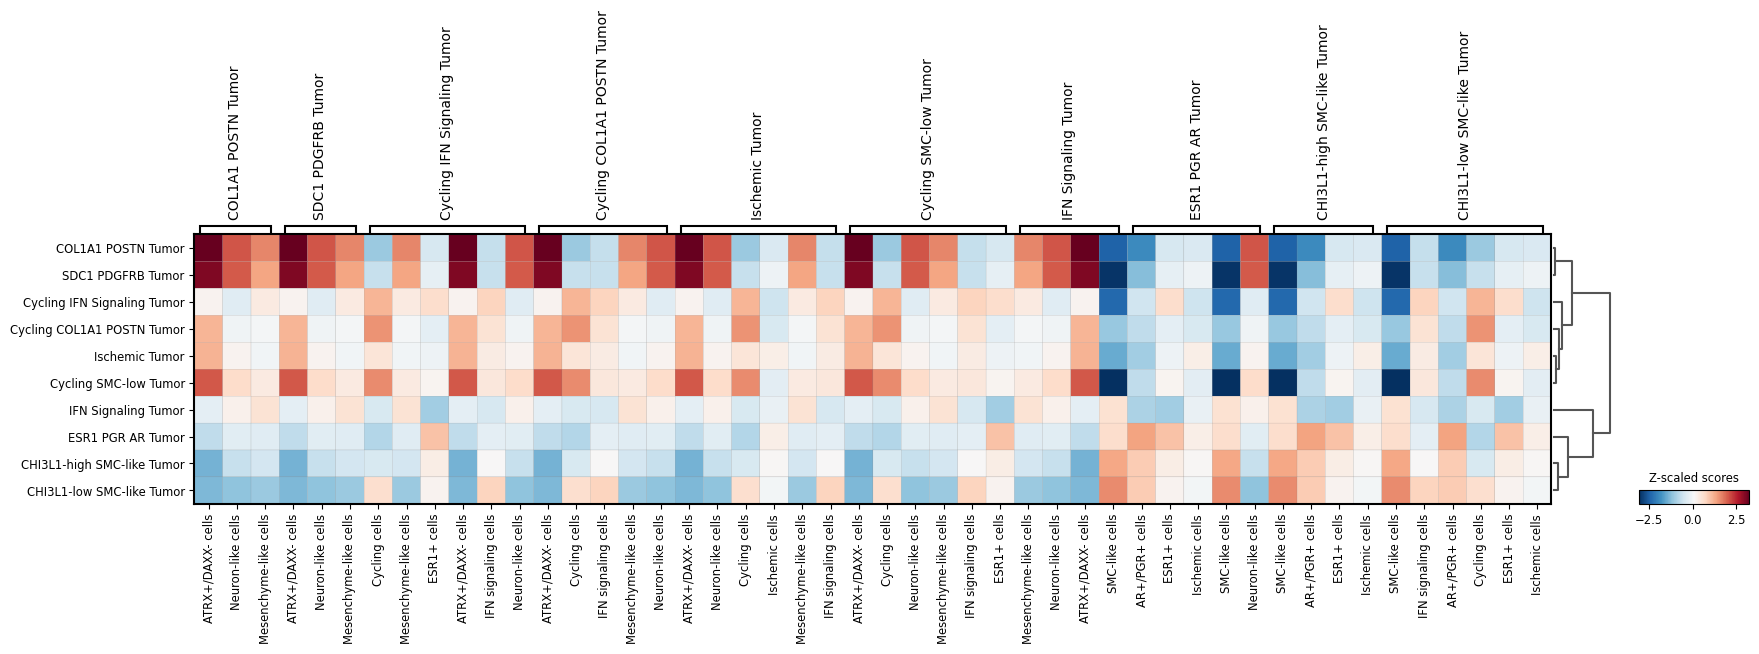

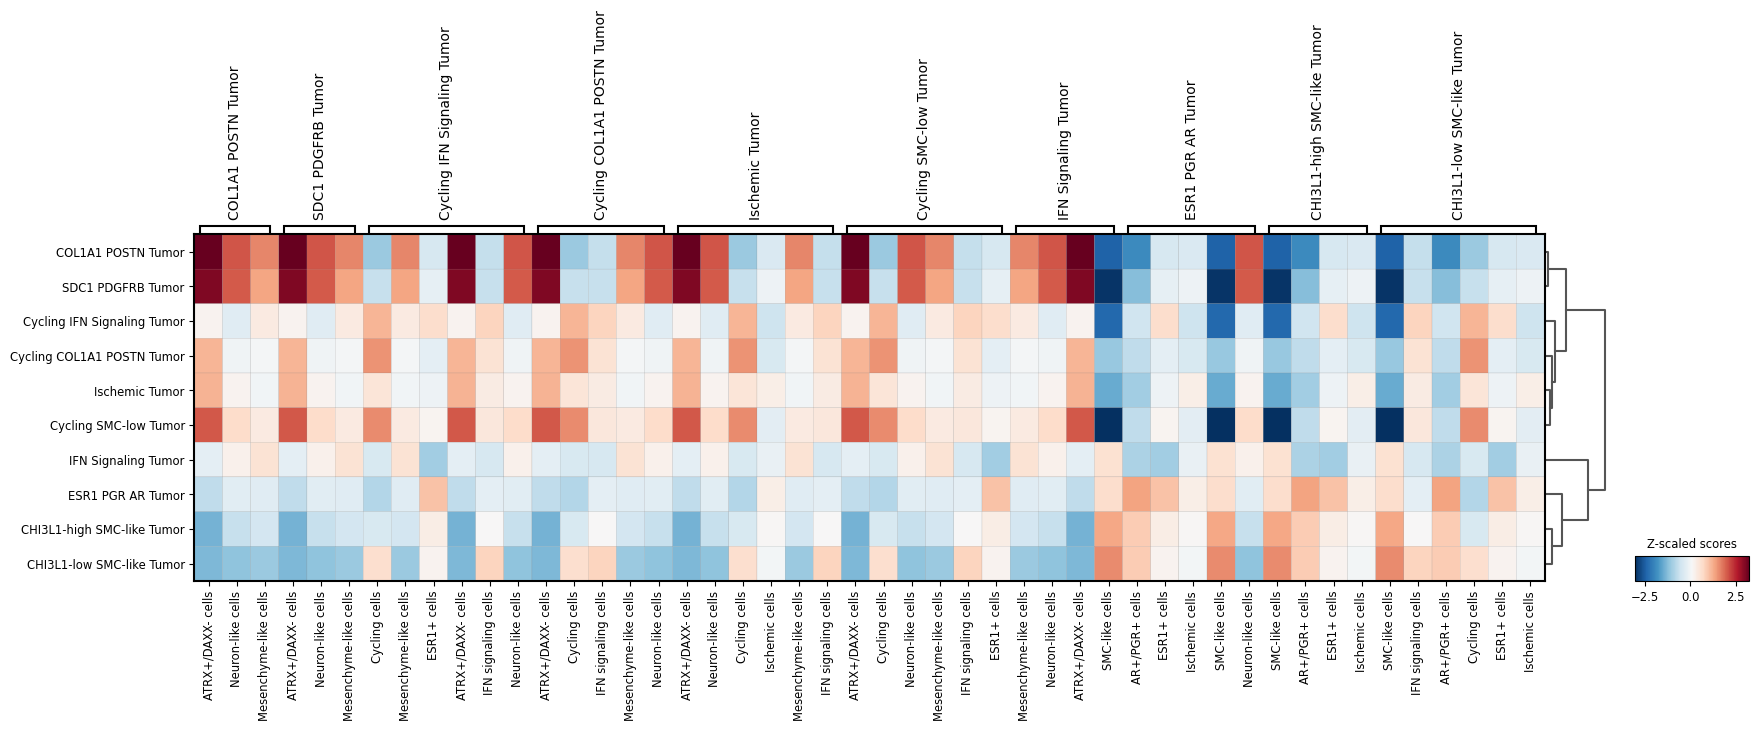

In [28]:
mp = sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby='tumor_subtype',
    dendrogram=True,
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
    return_fig=True,
)
mp.savefig(f'tumor_subtype_top{n_ctypes}.png', dpi=300)
mp.savefig(f'tumor_subtype_top{n_ctypes}.pdf', dpi=300)

# Look at each scVIVA leiden cluster

In [30]:
leiden_key = 'leiden0_8'

df = dc.tl.rankby_group(adata=score, groupby=leiden_key, reference="rest", method="wilcoxon")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,AR+/PGR+ cells,448.924384,2.465156,0.000000e+00,0.000000e+00
1,0,rest,SMC-like cells,395.714637,2.177786,0.000000e+00,0.000000e+00
2,0,rest,ESR1+ cells,290.152800,1.153089,0.000000e+00,0.000000e+00
3,0,rest,IFN signaling cells,211.654484,0.752544,0.000000e+00,0.000000e+00
4,0,rest,Cycling cells,95.594556,0.310737,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
145,16,rest,Cycling cells,100.632128,1.477254,0.000000e+00,0.000000e+00
146,16,rest,Neuron-like cells,78.258772,1.035261,0.000000e+00,0.000000e+00
147,16,rest,Mesenchyme-like cells,49.866388,0.686877,0.000000e+00,0.000000e+00
151,16,rest,IFN signaling cells,21.657190,0.201476,5.200013e-104,5.850015e-104


In [31]:
df.to_csv(OUTPUT_MASTER_DIR / f'dc_ranked_{leiden_key}_clusters.csv')

In [32]:
n_ctypes = 9
ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/local/scratch/jpagolia/slrmtmp.51600031/ipykernel_19713/2674100198.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'0': ['AR+/PGR+ cells',
  'SMC-like cells',
  'ESR1+ cells',
  'IFN signaling cells',
  'Cycling cells'],
 '1': ['SMC-like cells',
  'IFN signaling cells',
  'Cycling cells',
  'AR+/PGR+ cells'],
 '10': ['Ischemic cells',
  'Neuron-like cells',
  'ATRX+/DAXX- cells',
  'Mesenchyme-like cells',
  'SMC-like cells'],
 '11': ['ATRX+/DAXX- cells',
  'Neuron-like cells',
  'Cycling cells',
  'Ischemic cells',
  'Mesenchyme-like cells',
  'IFN signaling cells'],
 '12': ['Cycling cells',
  'ESR1+ cells',
  'IFN signaling cells',
  'AR+/PGR+ cells'],
 '13': ['Neuron-like cells',
  'SMC-like cells',
  'Ischemic cells',
  'Mesenchyme-like cells',
  'ATRX+/DAXX- cells'],
 '14': ['ATRX+/DAXX- cells', 'Neuron-like cells', 'Mesenchyme-like cells'],
 '15': ['ATRX+/DAXX- cells', 'Neuron-like cells', 'Mesenchyme-like cells'],
 '16': ['ATRX+/DAXX- cells',
  'Cycling cells',
  'Neuron-like cells',
  'Mesenchyme-like cells',
  'IFN signaling cells',
  'ESR1+ cells'],
 '2': ['SMC-like cells', 'AR+/PGR+ cel

2026-05-26 14:01:39 | [INFO] maxp pruned
2026-05-26 14:01:39 | [INFO] cmap pruned
2026-05-26 14:01:39 | [INFO] kern dropped
2026-05-26 14:01:39 | [INFO] post pruned
2026-05-26 14:01:39 | [INFO] FFTM dropped
2026-05-26 14:01:39 | [INFO] GPOS pruned
2026-05-26 14:01:39 | [INFO] GSUB pruned
2026-05-26 14:01:39 | [INFO] glyf pruned
2026-05-26 14:01:39 | [INFO] Added gid0 to subset
2026-05-26 14:01:39 | [INFO] Added first four glyphs to subset
2026-05-26 14:01:39 | [INFO] Closing glyph list over 'MATH': 50 glyphs before
2026-05-26 14:01:39 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'F', 'G', 'I', 'M', 'N', 'P', 'R', 'S', 'T', 'X', 'Z', 'a', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'period', 'plus', 'r', 's', 'seven', 'six', 'slash', 'space', 'three', 'two', 'u', 'y', 'zero']
2026-05-26 14:01:39 | [INFO] Glyph IDs:   [0, 1, 2, 3, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,

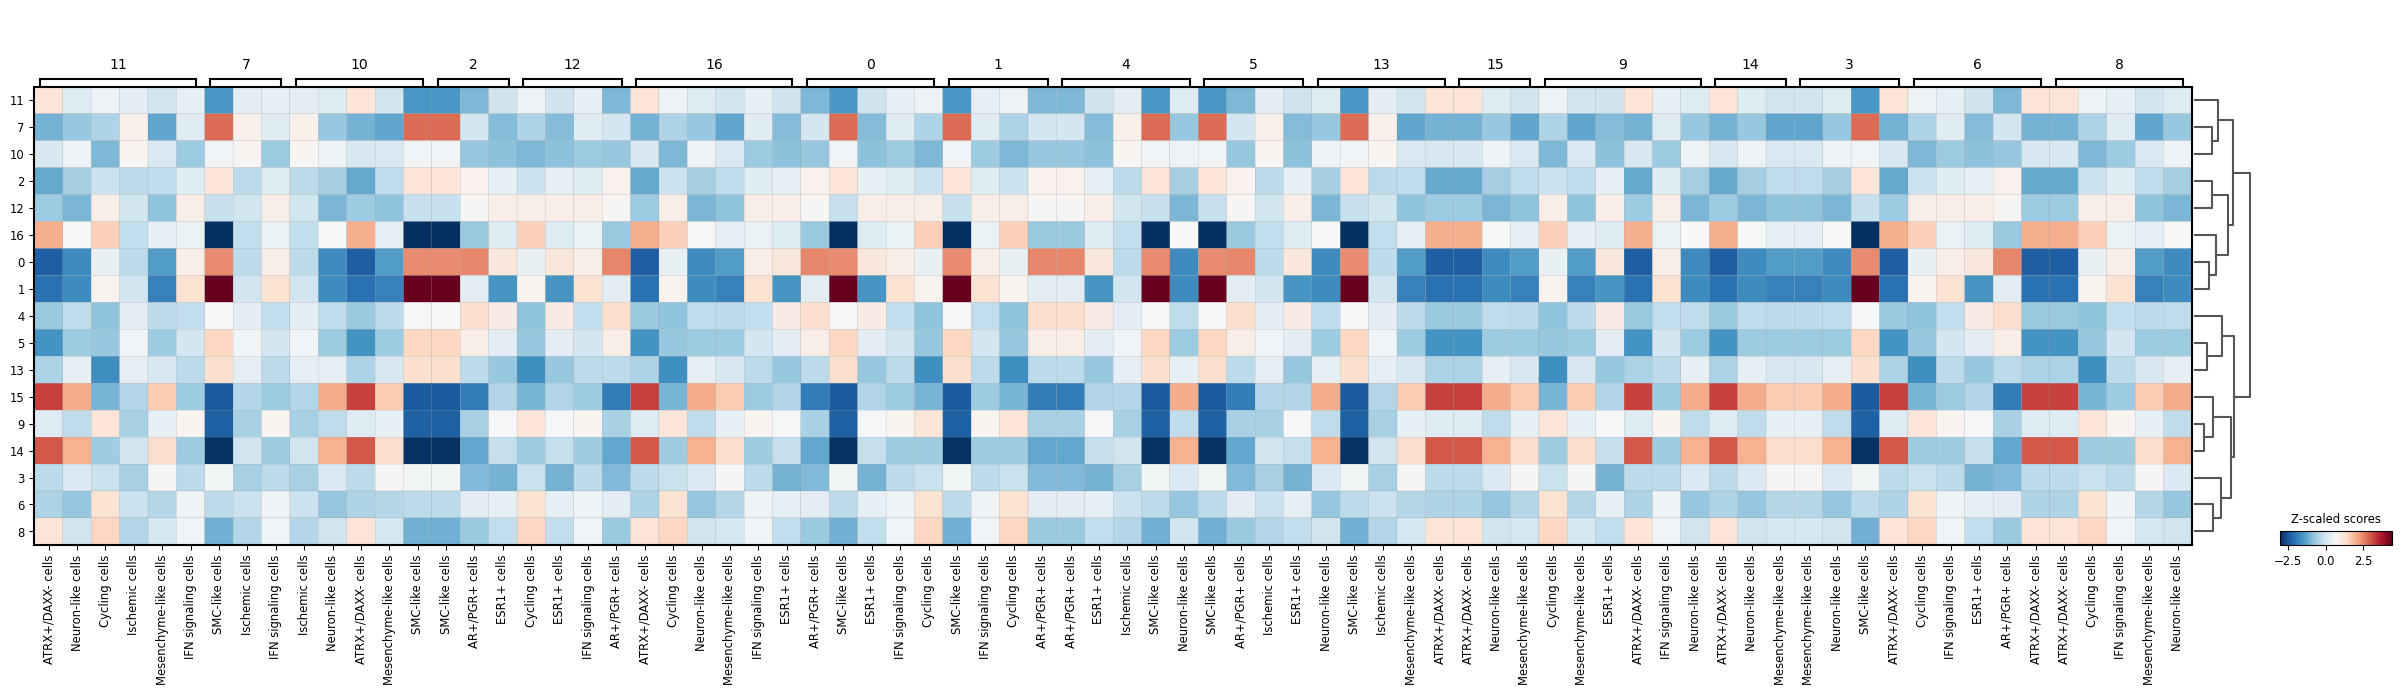

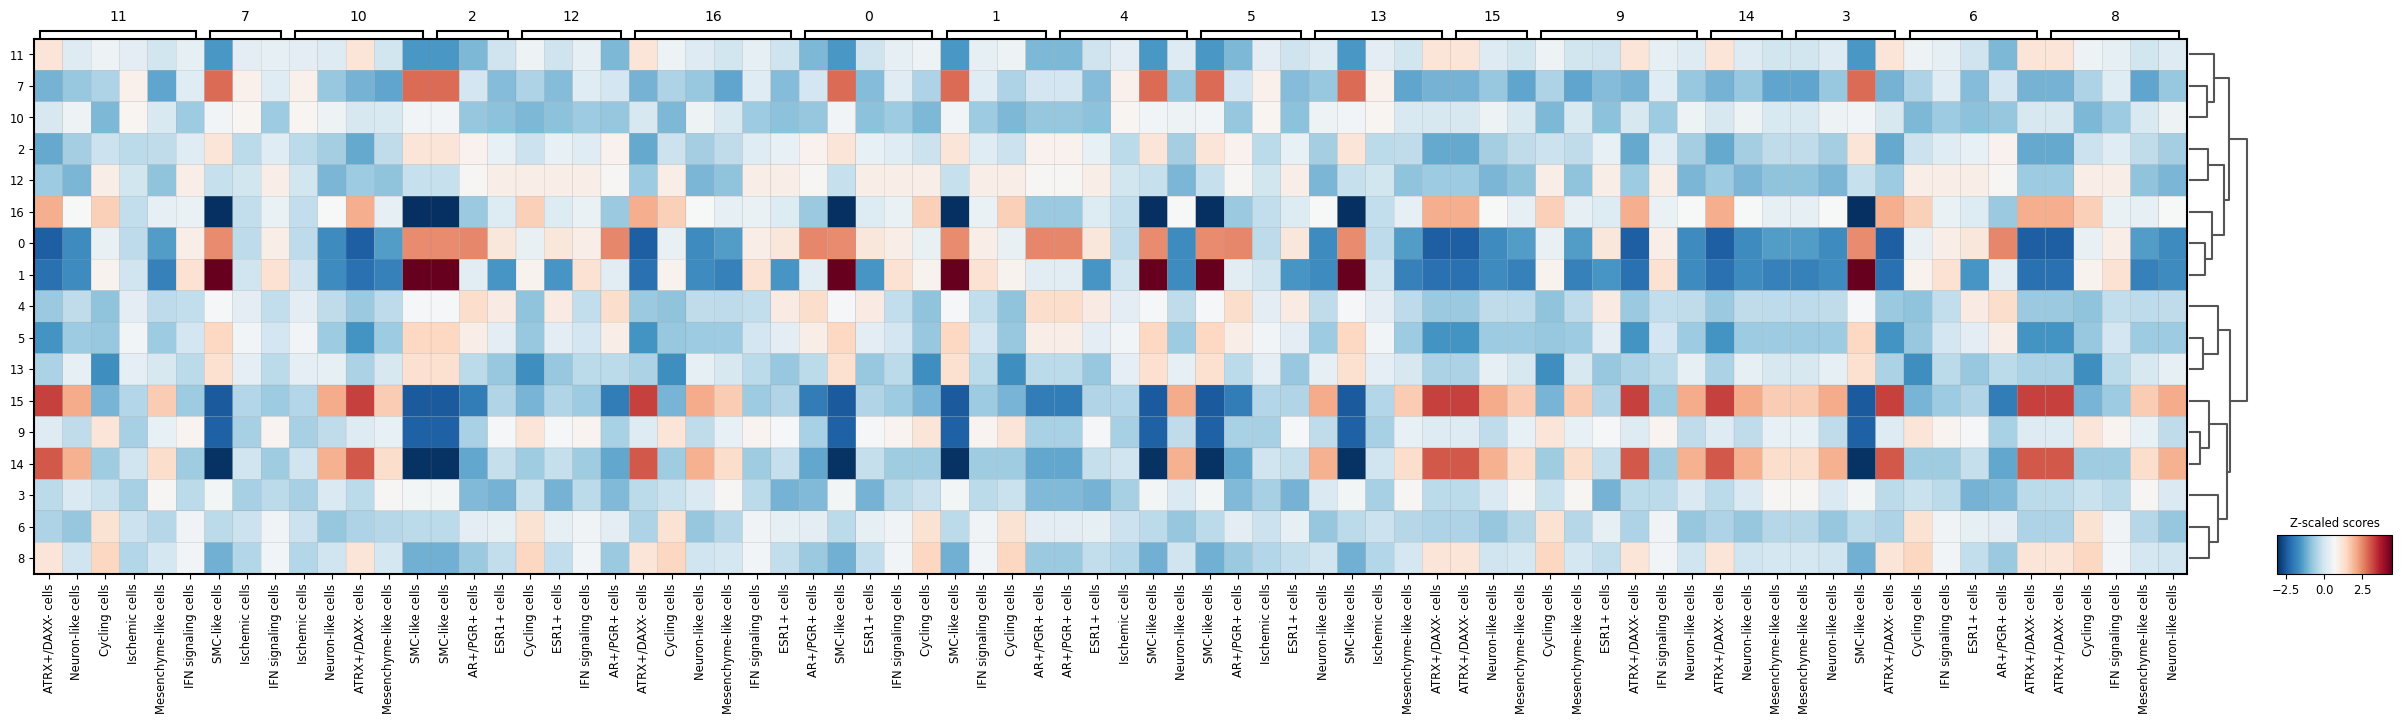

In [33]:
mp = sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby=leiden_key,
    dendrogram=True,
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
    return_fig=True,
)
mp.savefig(f'{leiden_key}_top{n_ctypes}.png', dpi=300)
mp.savefig(f'{leiden_key}_top{n_ctypes}.pdf', dpi=300)

# Reactome on the G4X tumor subtypes

In [34]:
adata

AnnData object with n_obs × n_vars = 1561027 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0', 'tumor_subtype'
    var: 'mean', 'std'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_le

In [35]:
msigdb = dc.op.resource(name='MSigDB', organism='human')
np.unique(msigdb['collection'])

array(['biocarta_pathways', 'cancer_cell_atlas',
       'cancer_gene_neighborhoods', 'cancer_modules',
       'cell_type_signatures', 'chemical_and_genetic_perturbations',
       'go_biological_process', 'go_cellular_component',
       'go_molecular_function', 'hallmark', 'human_phenotype_ontology',
       'immunesigdb', 'kegg_medicus_pathways', 'kegg_pathways',
       'mirna_targets_legacy', 'mirna_targets_mirdb',
       'oncogenic_signatures', 'pid_pathways', 'positional',
       'reactome_pathways', 'tf_targets_gtrf', 'tf_targets_legacy',
       'vaccine_response', 'wikipathways'], dtype=object)

In [36]:
network_name = 'reactome_pathways'
prefix = 'REACTOME_'
suffix = '_PATHWAY'

net = msigdb[msigdb['collection'] == network_name]
net = net.rename(columns={"geneset": "source", "genesymbol": "target"})
net = net.drop_duplicates(subset=['source', 'target'])
net = net[['target', 'source']]
net['source'] = net['source'].str.replace(prefix, '') # remove prefix
net['source'] = net['source'].str.replace(suffix, '') # remove suffix
net

,target,source
,,
0,A1BG,HEMOSTASIS
5,A1BG,RESPONSE_TO_ELEVATED_PLATELET_CYTOSOLIC_CA2
14,A1BG,INNATE_IMMUNE_SYSTEM
39,A1BG,PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION
44,A1BG,NEUTROPHIL_DEGRANULATION
...,...,...
5895204,ZZZ3,EPIGENETIC_REGULATION_BY_WDR5_CONTAINING_HISTO...
5895245,ZZZ3,FORMATION_OF_WDR5_CONTAINING_HISTONE_MODIFYING...
5895387,ZZZ3,CHROMATIN_ORGANIZATION


In [37]:
dc.mt.ulm(data=adata, net=net)

In [38]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 1561027 × 145
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0', 'tumor_subtype'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_leiden0_5', 'dendrogram_l

In [39]:
score.write_h5ad(f'{network_name}_score.h5ad')

## Look at G4X tumor subtypes

In [40]:
df = dc.tl.rankby_group(
    adata=score,
    groupby='tumor_subtype',
    reference='rest',
    method='wilcoxon',
)
df = df[df['stat'] > 0]
df.to_csv(f'{network_name}_scores.csv', index=False)
df

,group,reference,name,stat,meanchange,pval,padj
0,CHI3L1-low SMC-like Tumor,rest,MUSCLE_CONTRACTION,465.100684,1.450886,0.000000e+00,0.000000e+00
1,CHI3L1-low SMC-like Tumor,rest,SMOOTH_MUSCLE_CONTRACTION,390.007622,1.248264,0.000000e+00,0.000000e+00
2,CHI3L1-low SMC-like Tumor,rest,SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES_AND_RHOBTB3,332.856137,0.651602,0.000000e+00,0.000000e+00
3,CHI3L1-low SMC-like Tumor,rest,NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS,325.489847,0.626170,0.000000e+00,0.000000e+00
4,CHI3L1-low SMC-like Tumor,rest,RHO_GTPASE_EFFECTORS,253.383463,0.505352,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
1439,Cycling SMC-low Tumor,rest,METABOLISM_OF_AMINO_ACIDS_AND_DERIVATIVES,10.236475,-0.009056,1.361057e-24,1.461876e-24
1441,Cycling SMC-low Tumor,rest,TRANSPORT_OF_SMALL_MOLECULES,8.960481,0.014088,3.232648e-19,3.421415e-19
1443,Cycling SMC-low Tumor,rest,SARS_COV_2_HOST_INTERACTIONS,8.088698,-0.067246,6.030571e-16,6.290884e-16
1444,Cycling SMC-low Tumor,rest,CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,6.862694,0.032369,6.757405e-12,6.998741e-12


In [41]:
n_markers = 5
source_markers = (df.groupby("group").apply(lambda g: g.drop_duplicates(subset="name").head(n_markers)["name"].tolist()).to_dict())
source_markers

/local/scratch/jpagolia/slrmtmp.51600031/ipykernel_19713/1777424031.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  source_markers = (df.groupby("group").apply(lambda g: g.drop_duplicates(subset="name").head(n_markers)["name"].tolist()).to_dict())
/local/scratch/jpagolia/slrmtmp.51600031/ipykernel_19713/1777424031.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_markers = (df.groupby("group").apply(lambda g: g.drop_duplicates(subset="name").head(n_markers)["name"].tolist()).to_dict())


{'CHI3L1-high SMC-like Tumor': ['SMOOTH_MUSCLE_CONTRACTION',
  'MUSCLE_CONTRACTION',
  'TRANSCRIPTIONAL_REGULATION_BY_RUNX1',
  'FORMATION_OF_THE_CORNIFIED_ENVELOPE',
  'KERATINIZATION'],
 'CHI3L1-low SMC-like Tumor': ['MUSCLE_CONTRACTION',
  'SMOOTH_MUSCLE_CONTRACTION',
  'SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES_AND_RHOBTB3',
  'NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS',
  'RHO_GTPASE_EFFECTORS'],
 'COL1A1 POSTN Tumor': ['COLLAGEN_DEGRADATION',
  'INTEGRIN_CELL_SURFACE_INTERACTIONS',
  'DISEASES_ASSOCIATED_WITH_GLYCOSAMINOGLYCAN_METABOLISM',
  'SIGNALING_BY_PDGF',
  'DISEASES_OF_GLYCOSYLATION'],
 'Cycling COL1A1 POSTN Tumor': ['ECM_PROTEOGLYCANS',
  'REGULATION_OF_INSULIN_LIKE_GROWTH_FACTOR_IGF_TRANSPORT_AND_UPTAKE_BY_INSULIN_LIKE_GROWTH_FACTOR_BINDING_PROTEINS_IGFBPS',
  'DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX',
  'COLLAGEN_DEGRADATION',
  'ELASTIC_FIBRE_FORMATION'],
 'Cycling IFN Signaling Tumor': ['RESPIRATORY_SYNCYTIAL_VIRUS_RSV_ATTACHMENT_AND_ENTRY',
  'RESPIRATORY_SYNCYTIAL_VIRUS_I

2026-05-26 14:15:03 | [INFO] maxp pruned
2026-05-26 14:15:03 | [INFO] cmap pruned
2026-05-26 14:15:03 | [INFO] kern dropped
2026-05-26 14:15:03 | [INFO] post pruned
2026-05-26 14:15:03 | [INFO] FFTM dropped
2026-05-26 14:15:03 | [INFO] GPOS pruned
2026-05-26 14:15:03 | [INFO] GSUB pruned
2026-05-26 14:15:03 | [INFO] glyf pruned
2026-05-26 14:15:03 | [INFO] Added gid0 to subset
2026-05-26 14:15:03 | [INFO] Added first four glyphs to subset
2026-05-26 14:15:03 | [INFO] Closing glyph list over 'MATH': 57 glyphs before
2026-05-26 14:15:03 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'space', 'three', 'two', 'u', 'underscore', 'w', 'y', 'zero']
2026-05-26 14:15:03 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22,

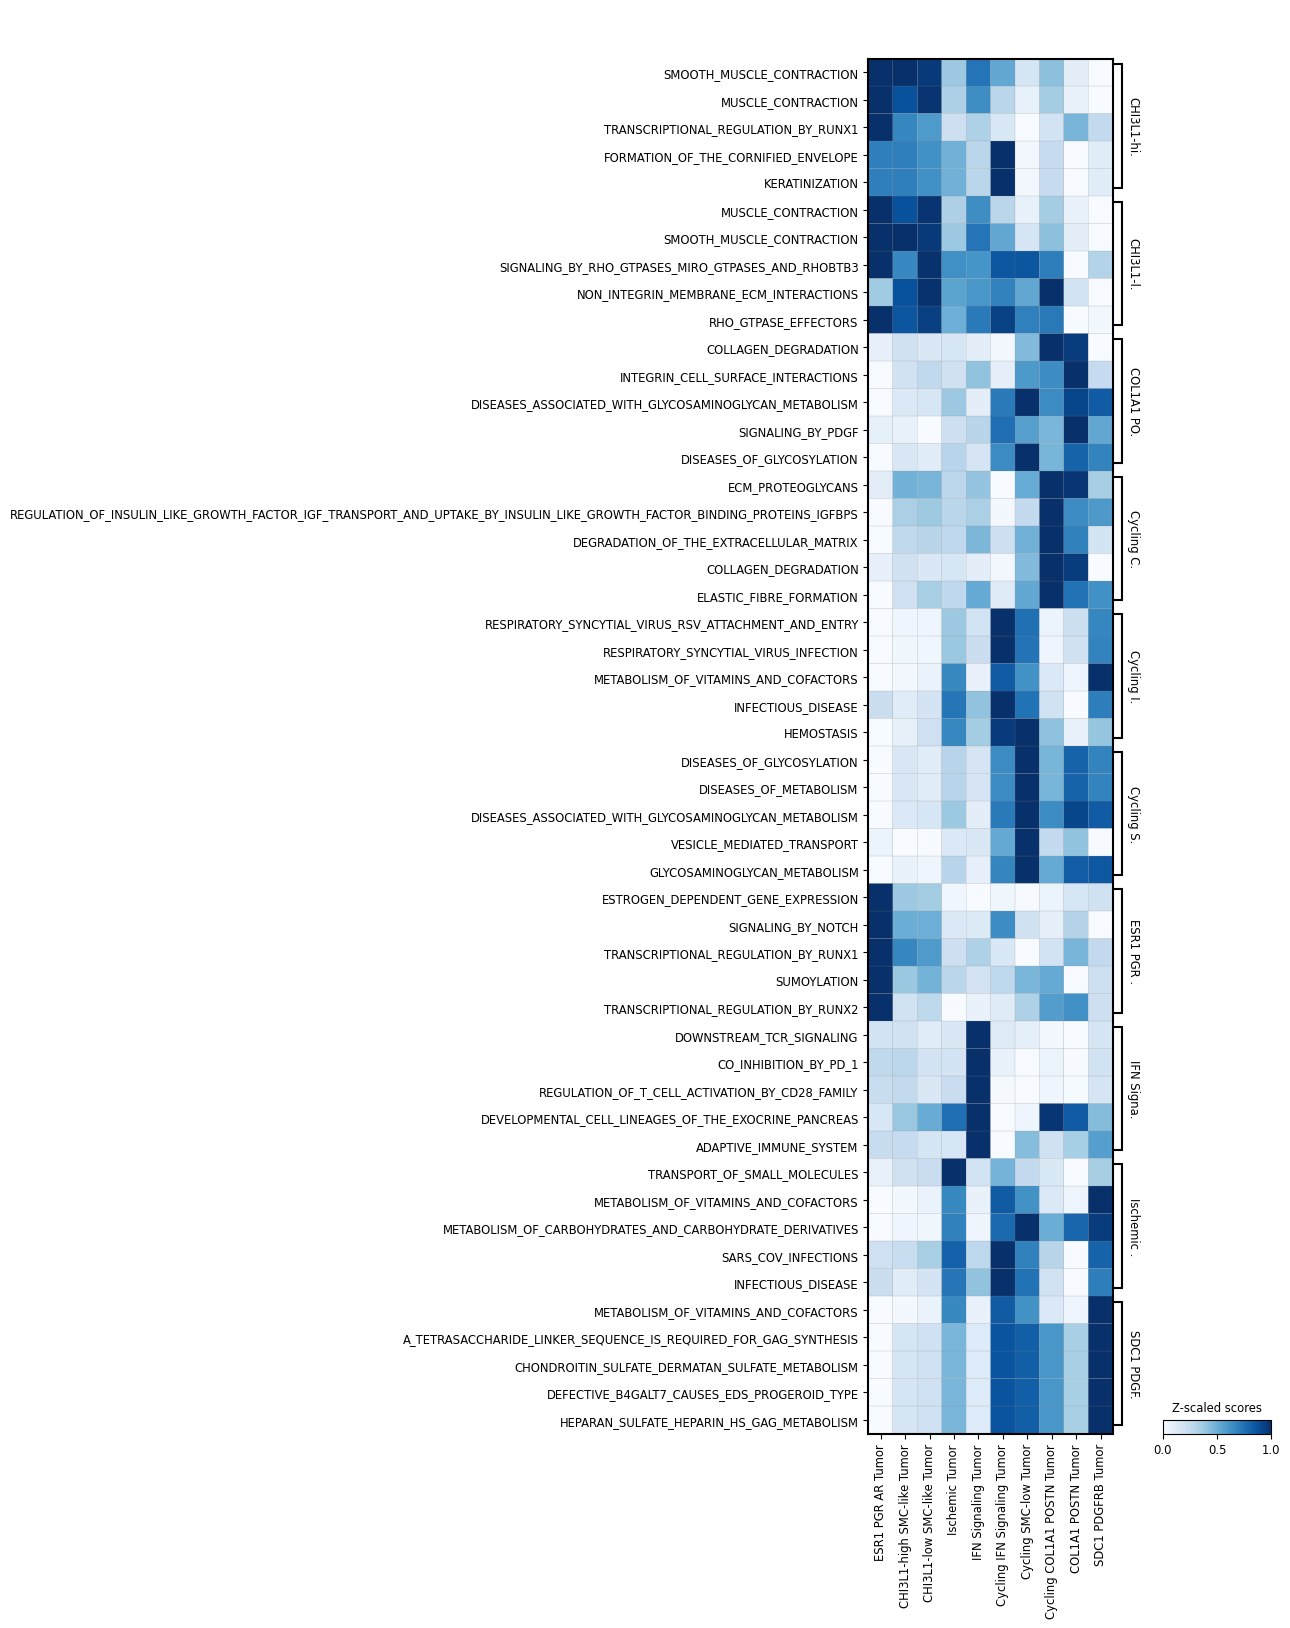

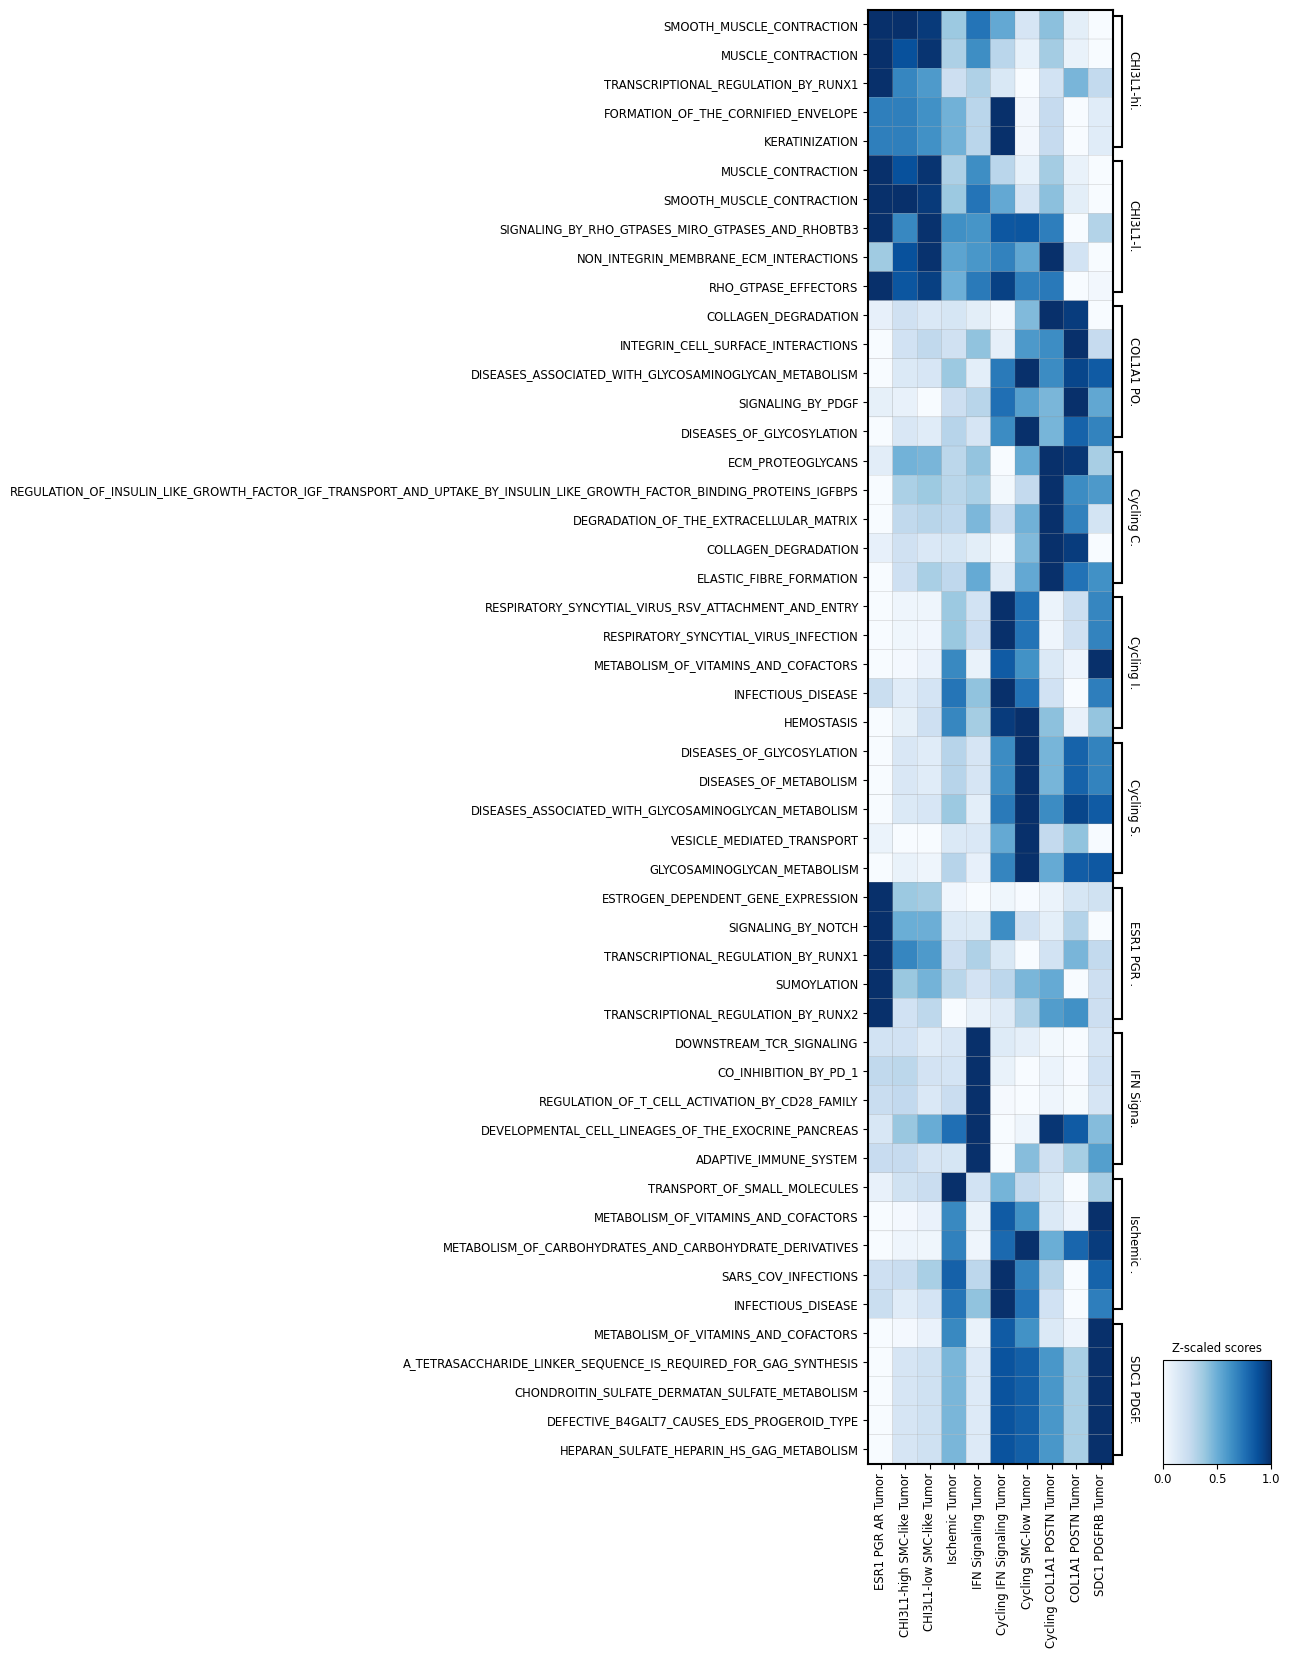

In [42]:
mp = sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby='tumor_subtype',
    dendrogram=False,
    standard_scale='var',
    colorbar_title='Z-scaled scores',
    cmap='Blues', 
    swap_axes=True,
    show=False,
    return_fig=True,
)
mp.savefig(f'top{n_markers}_{network_name}_mp.png', dpi=300)
mp.savefig(f'top{n_markers}_{network_name}_mp.pdf', dpi=300)

In [44]:
source_markers.keys()

dict_keys(['CHI3L1-high SMC-like Tumor', 'CHI3L1-low SMC-like Tumor', 'COL1A1 POSTN Tumor', 'Cycling COL1A1 POSTN Tumor', 'Cycling IFN Signaling Tumor', 'Cycling SMC-low Tumor', 'ESR1 PGR AR Tumor', 'IFN Signaling Tumor', 'Ischemic Tumor', 'SDC1 PDGFRB Tumor'])

In [47]:
# selected pathways
source_markers = {
    'ESR1 PGR AR Tumor' : [
        'ESTROGEN_DEPENDENT_GENE_EXPRESSION', 
        'ESR_MEDIATED_SIGNALING',
        'SIGNALING_BY_NUCLEAR_RECEPTORS'
    ],
    'CHI3L1-high SMC-like Tumor' : [
        'MUSCLE_CONTRACTION', 
        'SMOOTH_MUSCLE_CONTRACTION'
    ],
    'CHI3L1-low SMC-like Tumor' : [
        'MUSCLE_CONTRACTION', 
        'SMOOTH_MUSCLE_CONTRACTION'
    ],
    'Ischemic Tumor' : [
        'APOPTOSIS',
        'PROGRAMMED_CELL_DEATH',
        'TRANSPORT_OF_SMALL_MOLECULES'
    ],
    'IFN Signaling Tumor' : [
        'INTERFERON_SIGNALING',
        'INNATE_IMMUNE_SYSTEM',
        'CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION'
    ],
    'Cycling IFN Signaling Tumor' : [
        'INTERFERON_SIGNALING',
        'INFECTIOUS_DISEASE'
    ],
    'Cycling SMC-low Tumor' : [
        'DISEASES_OF_GLYCOSYLATION',
        'GLYCOSAMINOGLYCAN_METABOLISM',
        'INTEGRIN_CELL_SURFACE_INTERACTIONS'
    ],
    'Cycling COL1A1 POSTN Tumor' : [
        'ECM_PROTEOGLYCANS',
        'DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX',
        'COLLAGEN_DEGRADATION',
        'EXTRACELLULAR_MATRIX_ORGANIZATION'
    ],
    'COL1A1 POSTN Tumor' : [
        'COLLAGEN_DEGRADATION', 
        'EXTRACELLULAR_MATRIX_ORGANIZATION', 
        'DISEASES_ASSOCIATED_WITH_GLYCOSAMINOGLYCAN_METABOLISM',
        'DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX'
    ],
    'SDC1 PDGFRB Tumor' : [
        'GLYCOSAMINOGLYCAN_METABOLISM',
        'DISEASES_OF_GLYCOSYLATION',
        'DOWNSTREAM_SIGNAL_TRANSDUCTION'
    ],
}

2026-05-26 20:17:03 | [INFO] maxp pruned
2026-05-26 20:17:03 | [INFO] cmap pruned
2026-05-26 20:17:03 | [INFO] kern dropped
2026-05-26 20:17:03 | [INFO] post pruned
2026-05-26 20:17:03 | [INFO] FFTM dropped
2026-05-26 20:17:03 | [INFO] GPOS pruned
2026-05-26 20:17:03 | [INFO] GSUB pruned
2026-05-26 20:17:03 | [INFO] glyf pruned
2026-05-26 20:17:03 | [INFO] Added gid0 to subset
2026-05-26 20:17:03 | [INFO] Added first four glyphs to subset
2026-05-26 20:17:03 | [INFO] Closing glyph list over 'MATH': 50 glyphs before
2026-05-26 20:17:03 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'W', 'X', 'Y', 'Z', 'a', 'c', 'd', 'e', 'five', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'space', 'three', 'u', 'underscore', 'w', 'y', 'zero']
2026-05-26 20:17:03 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 22, 24, 36, 37, 38, 39, 40, 41, 42, 43, 44, 47, 48, 49,

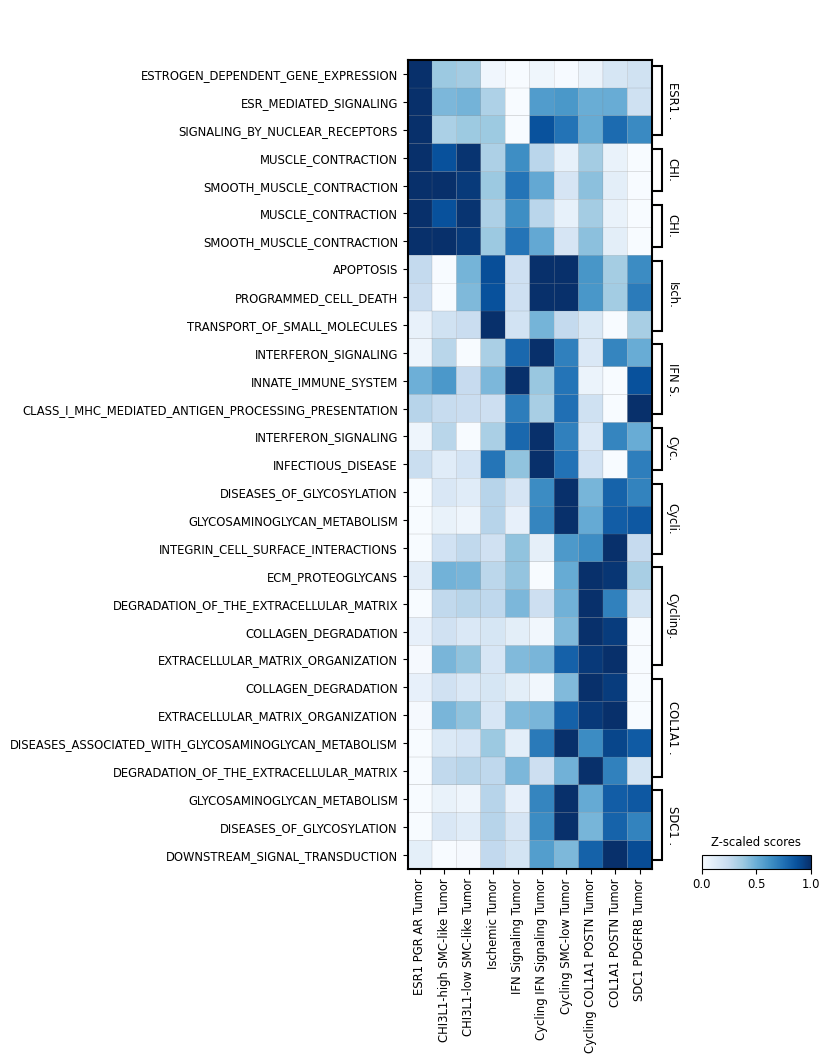

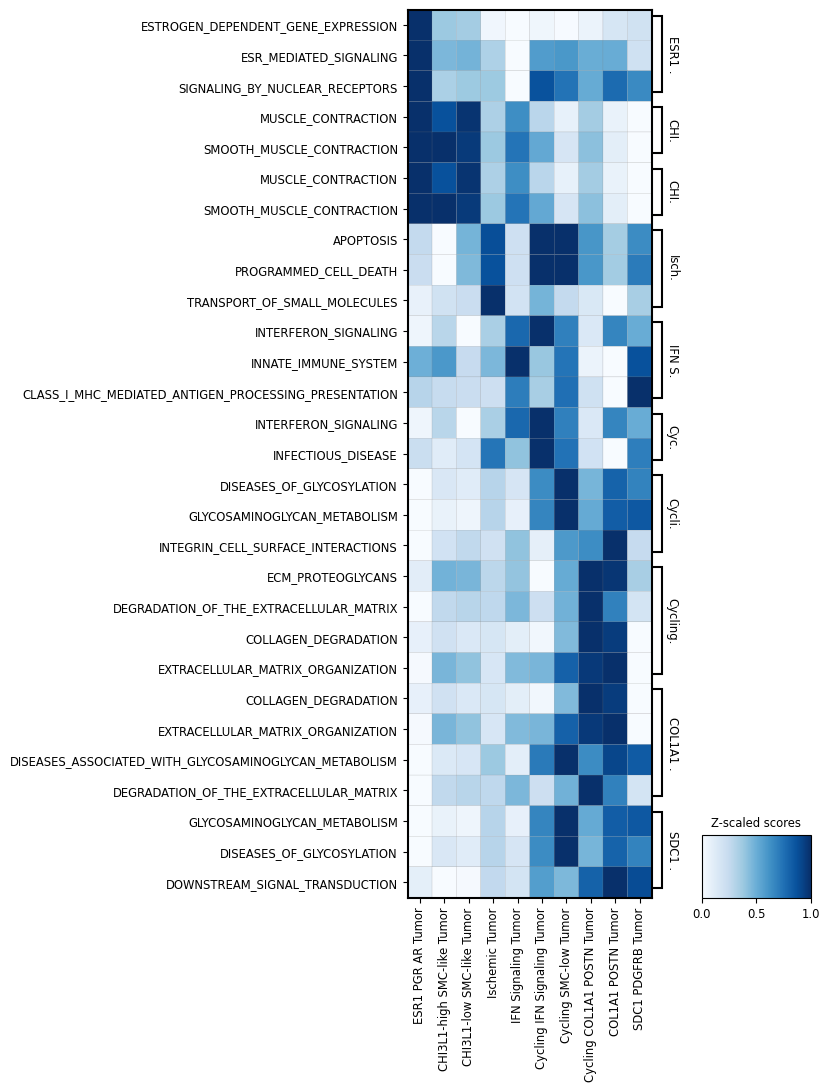

In [48]:
mp = sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby='tumor_subtype',
    dendrogram=False,
    standard_scale='var',
    colorbar_title='Z-scaled scores',
    cmap='Blues', 
    swap_axes=True,
    show=False,
    return_fig=True,
)
mp.savefig(f'selected_pathways_{network_name}_mp.png', dpi=300)
mp.savefig(f'selected_pathways_{network_name}_mp.pdf', dpi=300)

# Same thing - Reactome on scRNAseq but only G4X genes

In [ ]:
data_dir = SCRNASEQ_DIR / 'objects'
adata = sc.read_h5ad(data_dir / 'tumor_subset_raw.h5ad') # tumor cells only
adata

In [ ]:
# rename tumor clusters
tumor_map = {
    "0" : "ESR1+ cells",
    "1" : "IFN signaling cells",
    "2" : "Mesenchyme-like cells",
    "3" : "Cycling cells",
    "4" : "AR+/PGR+ cells",
    "5" : "Ischemic cells",
    "6" : "SMC-like cells",
    "7" : "Neuron-like cells",
    "8" : "ATRX+/DAXX- cells"
}
adata.obs['tumor_subtype'] = adata.obs['leiden0_2'].map(tumor_map)
adata.obs['tumor_subtype']

In [ ]:
adata.layers['counts'] = adata.X
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata

In [ ]:
data_dir = G4X_DIR / 'ref'
G4X_vars = pd.read_csv(data_dir / 'G4X_vars.txt', header=None)[0].to_list()
G4X_vars

In [ ]:
# subset to G4X genes
adata = adata[:, G4X_vars].copy()
adata

In [ ]:
adata = adata[adata.layers['counts'].sum(axis=1) > 1].copy()
adata

In [ ]:
dc.mt.ulm(data=adata, net=net)

In [ ]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

In [ ]:
df = dc.tl.rankby_group(
    adata=score,
    groupby='tumor_subtype',
    reference='rest',
    method='wilcoxon',
)
df = df[df['stat'] > 0]
df.to_csv(f'scRNAseq_{network_name}_scores.csv', index=False)
df

In [ ]:
n_markers = 5
source_markers = (df.groupby("group").apply(lambda g: g.drop_duplicates(subset="name").head(n_markers)["name"].tolist()).to_dict())
source_markers

In [ ]:
mp = sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby='tumor_subtype',
    dendrogram=False,
    standard_scale='var',
    colorbar_title='Z-scaled scores',
    cmap='Blues', 
    swap_axes=True,
    show=False,
    return_fig=True,
)
mp.savefig(f'scRNAseq_top{n_markers}_{network_name}_mp.png', dpi=300)
mp.savefig(f'scRNAseq_top{n_markers}_{network_name}_mp.pdf', dpi=300)